# BCO

In [2]:
# standard libraries
import pandas as pd
import numpy as np
import os
import random
import seaborn as sns

# visualizations
import matplotlib.pyplot as plt
from IPython.display import Image
from mlxtend.plotting import heatmap
from mlxtend.plotting import plot_decision_regions
%matplotlib inline

# sklearn
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import precision_score, recall_score, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

# tf
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import initializers

import math

2026-04-11 15:01:44.047993: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-11 15:01:45.530670: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-11 15:01:50.247903: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


---
## BCO Dataset Description

The BCO-DMO Global Bleaching & Environmental Dataset hosted by the Biological and Chemical Oceanography Data Management Office (BCO-DMO) compiles global coral bleaching observations from 1980 to 2020 with 62 different features such as site exposure, temperature, bleaching level, and more. The data is collected from seven sources: Reef Check, Donner et al. (2017), McClanahan et al. (2019), AGRRA (https://www.agrra.org), FRRP (https://ocean.floridamarine.org/FRRP/Home/Reports), Safaie et al. (2018), and Kumagai et al. (2018). This dataset can be used to include features that can predict reef health based on environmental events.

Dataset link: https://www.bco-dmo.org/dataset/773466

Original Dataset:

In [3]:
df_bco = pd.read_csv("global_bleaching_environmental.csv")
df_bco.head()

/tmp/ipykernel_26848/1550130468.py:1: DtypeWarning: Columns (0: Distance_to_Shore, 1: Turbidity, 2: Percent_Bleaching) have mixed types. Specify dtype option on import or set low_memory=False.
  df_bco = pd.read_csv("global_bleaching_environmental.csv")


,Site_ID,Sample_ID,Data_Source,Latitude_Degrees,Longitude_Degrees,Ocean_Name,Reef_ID,Realm_Name,Ecoregion_Name,Country_Name,...,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Date,Site_Comments,Sample_Comments,Bleaching_Comments
0,2501,10324336,Donner,23.163,-82.5260,Atlantic,nd,Tropical Atlantic,Cuba and Cayman Islands,Cuba,...,5,0,0,0.74,7.25,0.18,2005-09-15,nd,nd,nd
1,3467,10324754,Donner,-17.575,-149.7833,Pacific,nd,Eastern Indo-Pacific,Society Islands French Polynesia,French Polynesia,...,4,0,0.26,0.67,4.65,0.19,1991-03-15,The bleaching does not appear to have gained ...,The bleaching does not appear to have gained ...,nd
2,1794,10323866,Donner,18.369,-64.5640,Atlantic,nd,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United Kingdom,...,7,0,0,1.04,11.66,0.26,2006-01-15,nd,nd,nd
3,8647,10328028,Donner,17.760,-64.5680,Atlantic,nd,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,...,4,0,0,0.75,5.64,0.2,2006-04-15,nd,nd,nd
4,8648,10328029,Donner,17.769,-64.5830,Atlantic,nd,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,...,5,0,0,0.92,6.89,0.25,2006-04-15,nd,nd,nd


In [4]:
print('Shape of df BCO:', df_bco.shape)

Shape of df BCO: (41361, 62)


### Parameters

Column definitions and unit information

In [5]:
data_dict = pd.read_csv("coral_data_dict.csv")
data_dict

,Supplied Name,Supplied Description,Supplied Units,Standard Name
0,Site_ID,Unique identifier for each site,unitless,site
1,Sample_ID,Unique identifier for each sampling event,unitless,sample
2,Data_Source,Source of data set,unitless,sampling_method
3,Latitude_Degrees,Latitude coordinates (positive vaues = North; ...,degrees North,latitude
4,Longitude_Degrees,Longitude coordinates (positive values = East;...,degrees East,longitude
...,...,...,...,...
57,TSA_DHWMean,The mean TSA_DHW over the entire time period,weeks,time_elapsed
58,Date,date of sampling event in format YYYY-MM-DD,%Y-%m-%d,date
59,Site_Comments,comments of any issues with the site or additi...,unitless,comment
60,Sample_Comments,comments of any issue or additional informatio...,unitless,comment


---
## BCO Preprocessing

 The BCO-DMO coral bleaching dataset had already undergone extensive preprocessing prior to this project. Earlier cleaning steps by the data curators included:
 
 * Standardizing column names
 * Handling missing values
 * Removing special characters from text fields
 * Formatting dates consistently
 
 They also corrected for:
 * Text formatting
 * Reordered columns for readability 
 * Rounded numeric values to consistent precision
 
 These steps ensured the dataset was largely standardized and analysis-ready before our team began working with it. 
 
 **Our team did the following transformations and named the dataset "bco_cleaned.csv". Code was developed by Mackenzie Henderson**: 

 Notebook: BCO_Preprocessing.ipynb (Mackenzie)

 * All "nd" entries were replaced with NaN to properly represent missing values. 
 * Key numeric columns, including Latitude_Degrees, Longitude_Degrees, Distance_to_Shore, Turbidity, and Cyclone_Frequency, were converted to numeric types. 
 * A unified Date column was also created from the separate year, month, and day fields to facilitate time-based analyses. There were no major outliers across the key variables.



In [6]:
df = pd.read_csv("bco_cleaned.csv")
print('Shape of df BCO Cleaned:', df.shape)
print("number of columnns: ", df.shape[1])
print("number of rows: ", df.shape[0])
print("column names:", df.columns)
print("number of unique values:\n",df.nunique())

Shape of df BCO Cleaned: (41361, 62)
number of columnns:  62
number of rows:  41361
column names: Index(['Site_ID', 'Sample_ID', 'Data_Source', 'Latitude_Degrees',
       'Longitude_Degrees', 'Ocean_Name', 'Reef_ID', 'Realm_Name',
       'Ecoregion_Name', 'Country_Name', 'State_Island_Province_Name',
       'City_Town_Name', 'Site_Name', 'Distance_to_Shore', 'Exposure',
       'Turbidity', 'Cyclone_Frequency', 'Date_Day', 'Date_Month', 'Date_Year',
       'Depth_m', 'Substrate_Name', 'Percent_Cover', 'Bleaching_Level',
       'Percent_Bleaching', 'ClimSST', 'Temperature_Kelvin',
       'Temperature_Mean', 'Temperature_Minimum', 'Temperature_Maximum',
       'Temperature_Kelvin_Standard_Deviation', 'Windspeed', 'SSTA',
       'SSTA_Standard_Deviation', 'SSTA_Mean', 'SSTA_Minimum', 'SSTA_Maximum',
       'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation',
       'SSTA_FrequencyMax', 'SSTA_FrequencyMean', 'SSTA_DHW',
       'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 

**Further preprocessing was done on the bco_cleaned dataset - code developed by Priyanka Bhatnagar and further improved by Paola Piety in this notebook** 

Original EDA Notebook: BCO_EDA.ipynb (Paola)

Improved EDA Notebook: BCO_Prep_EDA.ipynb (Priyanka)

Final Notebook: Current notebook (Paola)

In [7]:
df.rename(columns=str.lower, inplace=True)

In [8]:
print(data_dict['Supplied Units'].value_counts())

Supplied Units
unitless                   21
degrees Celsius            14
weeks                       8
SSTA per time period        4
TSA per time period         4
meters (m)                  2
percent                     2
Kelvin                      2
degrees North               1
degrees East                1
reciprocal meters (m-1)     1
meters per hour             1
%Y-%m-%d                    1
Name: count, dtype: int64


Upon visual inspection of the unitless columns, the site_id, sample_id, reef_id, site_name, site_comments, sample_comments, bleaching_comments can be dropped, as they're unique and have no predictive power; the comments are unstructured text.

Geographic categorical variables, like Ocean_name, Realm_name, ecoregion_name, country_name, etc can be dropped as well, due to high cardinality and redundancy with latitude and longitude, which already capture spatial variation.

bleaching_level looks like being similar to the target variable and should be dropped.

Categorical columns to keep: exposure, cyclone frequency, substrate_name, date columns.

In [9]:
# Drop unwanted unitless columns:

cols_to_drop = ['site_id', 'sample_id', 'data_source', 'ocean_name', 'reef_id', 'realm_name',
       'ecoregion_name', 'country_name', 'state_island_province_name', 'city_town_name', 'site_name',
        'bleaching_level', 'site_comments', 'sample_comments', 'bleaching_comments']

df = df.drop(columns=cols_to_drop)
print(df.shape)

(41361, 47)


In [10]:
missing_values = df.isna().sum().sort_values(ascending=False)
missing_percent = (missing_values/ len(df)) *100
missing_summary = pd.DataFrame(
    {'missing_count': missing_values,
    'missing_percent': missing_percent}
    ).sort_values(by='missing_percent', ascending=False)

missing_summary.head()

,missing_count,missing_percent
substrate_name,12668,30.627886
percent_cover,12455,30.112908
percent_bleaching,6846,16.551824
depth_m,1799,4.349508
ssta_minimum,176,0.425522


- Keep the lat and long columns.  
- ClimSST - The climatological baseline SST. Essential for checking relative stress.
- We can keep the temperature_mean as it represents the central tendency, but if its correlated with ClimSST, we can drop later. 
- temperature_maximum shows absolute extremes and capture acute stress events, we can keep this and ~~drop temperature_minimum.~~
- ~~Out of the SSTA (sea surface temp anomaly) we can keep SSAT, SSTA_std_dev and SSTA max.~~
- drop ~~ssta mean~~ and tsa mean.
- ~~drop ssta_min and tsa_min as cool anomalies don’t cause bleaching.~~
- out of the TSA (thermal stress anomaly) we can keep TSA, TSA std dev and TSA max, but check collinearity with SSTA and drop later.
- drop day, month and year columns as date column has it already, so redundant with date
- Kelvin units: temperature_kelvin, temperature_kelvin_standard_deviation. Same info as Celsius columns.

In [11]:
# temp_cols_to_drop = ['date_day', 'date_month', 'date_year', 'temperature_kelvin',  
#                      'temperature_kelvin_standard_deviation', 'ssta_mean', 'ssta_minimum', 'tsa_minimum', 
#                      'tsa_mean']

temp_cols_to_drop = ['date_day', 'date_month', 'date_year', 'temperature_kelvin',  
                     'temperature_kelvin_standard_deviation', 'ssta_mean']

df = df.drop(columns=temp_cols_to_drop)
print(df.shape)

(41361, 41)


In [12]:
df.columns

Index(['latitude_degrees', 'longitude_degrees', 'distance_to_shore',
       'exposure', 'turbidity', 'cyclone_frequency', 'depth_m',
       'substrate_name', 'percent_cover', 'percent_bleaching', 'climsst',
       'temperature_mean', 'temperature_minimum', 'temperature_maximum',
       'windspeed', 'ssta', 'ssta_standard_deviation', 'ssta_minimum',
       'ssta_maximum', 'ssta_frequency', 'ssta_frequency_standard_deviation',
       'ssta_frequencymax', 'ssta_frequencymean', 'ssta_dhw',
       'ssta_dhw_standard_deviation', 'ssta_dhwmax', 'ssta_dhwmean', 'tsa',
       'tsa_standard_deviation', 'tsa_minimum', 'tsa_maximum', 'tsa_mean',
       'tsa_frequency', 'tsa_frequency_standard_deviation', 'tsa_frequencymax',
       'tsa_frequencymean', 'tsa_dhw', 'tsa_dhw_standard_deviation',
       'tsa_dhwmax', 'tsa_dhwmean', 'date'],
      dtype='str')

- **percent_cover** : measures how much substrate space a species occupies. It's about relative abundance of organisms on the reef floor. But its different from percent_bleaching. E.g. A reef could have 80% coral cover (lots of coral)  30% bleaching (30% of that coral is bleached). So, they're independent measurements.
- **substrate_name** -type of substrate from Reef Check data. Hard Coral, Nutrient Indicator Algae, Fleshy Seaweed.
- **bleaching_level** is not useful for imputation, it's just a site-level descriptor with one value.
- **percent_bleaching** - is an average of four transect segments (Reef Check) or average of a bleaching code. Need to check the data collection method for precent_bleaching.

``It is possible that data was collected overtime, sites may have been surveyed for physical/environmental parameters first, with biological assessments (bleaching) added in a later expedition. This would produce rows with complete feature data but missing percent_bleaching.``

``Its worth checking if the same site was surveyed multiple times across years, as that would result in duplicate rows.``

In [13]:
df.isna().sum().sort_values(ascending=False)

substrate_name                       12668
percent_cover                        12455
percent_bleaching                     6846
depth_m                               1799
ssta_minimum                           176
ssta                                   148
ssta_frequency                         148
tsa_dhw                                148
ssta_dhw                               148
tsa_frequency                          148
tsa                                    148
tsa_mean                               132
tsa_frequency_standard_deviation       132
tsa_standard_deviation                 132
tsa_minimum                            132
ssta_dhw_standard_deviation            132
ssta_dhwmean                           132
ssta_frequency_standard_deviation      132
ssta_frequencymax                      132
temperature_maximum                    132
ssta_maximum                           132
ssta_frequencymean                     132
ssta_standard_deviation                132
temperature

In [14]:
# Check for duplicate rows
print(f"Total rows: {len(df)}")
print(f"Fully duplicate rows: {df.duplicated().sum()}")

# Check for duplicate sites with same location (lat/ long) but different dates
location_date_dupes = df.duplicated(
    subset=['latitude_degrees', 'longitude_degrees', 'date'], 
    keep=False
)

print(f"Same location + date duplicates: {location_date_dupes.sum()}")

# How many unique sites?
unique_sites = df.groupby(['latitude_degrees', 'longitude_degrees']).size().reset_index(name='survey_count')

print(f"\nUnique lat/long locations: {len(unique_sites)}")
print(f"Sites surveyed more than once:")
print(unique_sites['survey_count'].value_counts().head(10))

Total rows: 41361


Fully duplicate rows: 56
Same location + date duplicates: 34074

Unique lat/long locations: 12323
Sites surveyed more than once:
survey_count
1     5951
2     2582
4     1609
6      453
8      365
12     178
3      166
10     165
5      139
16     110
Name: count, dtype: int64


As we get 56 fully duplicated rows, we decided to remove them from the dataset as this will guarantee unique observations with minimal impact when dropped. 

In [15]:
# Drop the 56 fully duplicated rows
df = df.drop_duplicates()
df.shape

(41305, 41)

Our model’s objective is to classify unseen observations by **predicting bleaching risk**, using "percent_bleaching" column as the basis for generating a new target variable, **bleaching_class**. Research in previous studies shows that classification can be made the following way: We grouped the continuous bleaching percentages into three ordinal levels of (low <1, medium 1-30, and high >30), each representing a different level of bleaching severity.

Articles: 
https://www.researchgate.net/publication/394532865_Moving_Beyond_Temperature_Metrics_in_Coral_Bleaching_Prediction_Using_Interpretable_Machine_Learning

https://www.aims.gov.au/research-topics/environmental-issues/coral-bleaching/coral-bleaching-events

During preprocessing, we found that "percent_bleaching" variable includes 6,846 (16.55%) null entries due to missing bleaching percentages. Because these labels are essential for supervised learning, we will need to reduce the dataset size by removing observations without valid bleaching data.


Dataframes created:
- **df_supervised** Semi-supervised learning - train on labeled rows, then use the model's predictions on unlabeled rows as - pseudo-labels and iterate. This technique could be relevant to ecological datasets where labeling is expensive.
- **df_unlabeled** Unsupervised clustering - the unlabeled rows can participate in finding natural groupings in the feature space.


In [16]:
#risk class
# <= 10 Low
# 11 - 30 Medium
# 31 High

# we grouped these data into three ordinal levels of no (Score 0, < 1% bleached), minor (Score 1, 2, 1%–30% bleached) and major (Score 3–4, > 30% bleached) bleaching to improve model predictive accuracy.

#df['bleaching_class'] = pd.cut(df["percent_bleaching"],bins=[-0.01, 10, 30, 100], labels=[0, 1, 2]) 
df['bleaching_class'] = pd.cut(df["percent_bleaching"],bins=[-0.01, 1, 30, 100], labels=[0, 1, 2]) 
df["bleaching_class"].value_counts()

bleaching_class
0    19926
1    10265
2     4277
Name: count, dtype: int64

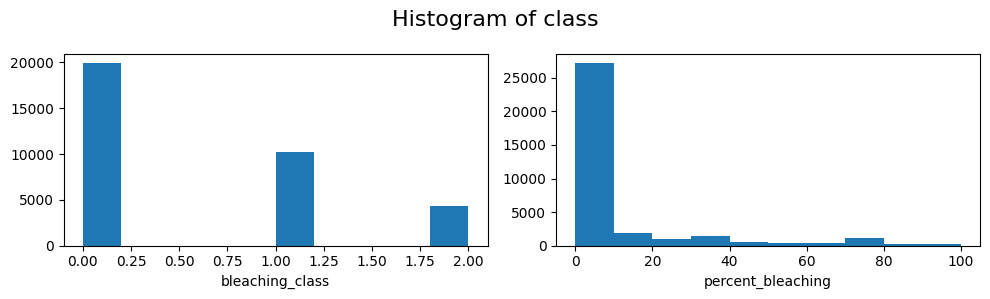

In [17]:
# YOUR CODE HERE
columns = ['bleaching_class', 'percent_bleaching']
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,3))
for idx, ax in enumerate(axes.flatten()):
    # plot histogram
    ax.hist(df[columns[idx]])
    # set xlabel
    ax.set_xlabel(columns[idx])


fig.suptitle("Histogram of class", fontsize=16)
plt.tight_layout()
plt.show()

In [18]:
print(df['percent_bleaching'].describe())
print(f"\nZero bleaching: {(df['percent_bleaching'] == 0).sum()} rows ({(df['percent_bleaching'] == 0).mean()*100:.1f}%)")
print(f"100% bleaching: {(df['percent_bleaching'] == 100).sum()} rows")
print(f"Out of range:   {((df['percent_bleaching'] < 0) | (df['percent_bleaching'] > 100)).sum()} rows")

count    34468.000000
mean         9.604955
std         20.163138
min          0.000000
25%          0.000000
50%          0.250000
75%          6.000000
max        100.000000
Name: percent_bleaching, dtype: float64

Zero bleaching: 16614 rows (40.2%)
100% bleaching: 118 rows
Out of range:   0 rows


The distribution of the derived "bleaching_class" from "percent_bleaching" column and the "percent_bleaching" colkumn itselft are severely zero-inflated and right-skewed with 40.2% of observations being 0. Nearly half of our dataset recorded no bleaching at all. Median is 0.25%, meaning more than half the dataset is "no bleaching". Mean is 9.6% but std is 20.2%, the mean is being pulled hard by a long right tail. 75th percentile is only 6%, so 75% of data has less than 6% bleaching.

In [19]:
# drop percent bleaching as that's part of how the target class was created
df = df.drop(columns=['percent_bleaching'])

# Supervised subset - only rows where target is known
df_supervised = df.dropna(subset=['bleaching_class']).copy()

# Unlabeled pool - rows where target is missing (for future semi-supervised work)
df_unlabeled = df[df['bleaching_class'].isna()].copy()


print('Shape of df BCO:', df_bco.shape)
print(f"Full dataset:   {df.shape}")
print(f"Supervised:     {df_supervised.shape}")
print(f"Unlabeled pool: {df_unlabeled.shape}")

Shape of df BCO: (41361, 62)
Full dataset:   (41305, 41)
Supervised:     (34468, 41)
Unlabeled pool: (6837, 41)


In [20]:
# # Export to csv for modelling
#df_supervised.to_csv('bco_supervised_clean.csv', index=False)

Our inputs include the environmental and site variables, and our target of interest is the risk level for coral bleaching (low, medium, or high), determined from the percentage bleach variable in the dataset. Before preprocessing, the dataset contained 41,361 rows and 62 columns. 

After preprocessing, the dataset contained now (41,305, 41). A dataset for supervised modeling (removing nulls in target variable) was developed from the processed dataset which contains (34,468, 41) and unsupervised dataset with (6,837, 41).

### Supervised Dataset Preprocessing and EDA

In [21]:
print("number of columnns: ", df_supervised.shape[1])
print("number of rows: ", df_supervised.shape[0])
print("column names:", df_supervised.columns)
print("number of unique values:\n",df_supervised.nunique())
print("unique values in bleaching_class column: ", df_supervised["bleaching_class"].unique())

number of columnns:  41
number of rows:  34468
column names: Index(['latitude_degrees', 'longitude_degrees', 'distance_to_shore',
       'exposure', 'turbidity', 'cyclone_frequency', 'depth_m',
       'substrate_name', 'percent_cover', 'climsst', 'temperature_mean',
       'temperature_minimum', 'temperature_maximum', 'windspeed', 'ssta',
       'ssta_standard_deviation', 'ssta_minimum', 'ssta_maximum',
       'ssta_frequency', 'ssta_frequency_standard_deviation',
       'ssta_frequencymax', 'ssta_frequencymean', 'ssta_dhw',
       'ssta_dhw_standard_deviation', 'ssta_dhwmax', 'ssta_dhwmean', 'tsa',
       'tsa_standard_deviation', 'tsa_minimum', 'tsa_maximum', 'tsa_mean',
       'tsa_frequency', 'tsa_frequency_standard_deviation', 'tsa_frequencymax',
       'tsa_frequencymean', 'tsa_dhw', 'tsa_dhw_standard_deviation',
       'tsa_dhwmax', 'tsa_dhwmean', 'date', 'bleaching_class'],
      dtype='str')


number of unique values:
 latitude_degrees                      9747
longitude_degrees                     9671
distance_to_shore                    10558
exposure                                 3
turbidity                             1474
cyclone_frequency                     1629
depth_m                                461
substrate_name                           3
percent_cover                          348
climsst                                948
temperature_mean                       755
temperature_minimum                    955
temperature_maximum                    633
windspeed                               18
ssta                                   614
ssta_standard_deviation                120
ssta_minimum                           365
ssta_maximum                           540
ssta_frequency                         386
ssta_frequency_standard_deviation      638
ssta_frequencymax                      294
ssta_frequencymean                     147
ssta_dhw                    

In [ ]:
target = pd.DataFrame(df_supervised, columns=['bleaching_class'])

features = pd.DataFrame(df_supervised, columns=['latitude_degrees', #1
       'longitude_degrees', 'distance_to_shore', 'turbidity', 'cyclone_frequency',  #4
       'depth_m', 'percent_cover', 'climsst', #3
       'temperature_mean', 'temperature_minimum', 'temperature_maximum', #3
       'windspeed', 'ssta', 'ssta_standard_deviation', #3
       'ssta_minimum', 'ssta_maximum', 'ssta_frequency', #3
       'ssta_frequency_standard_deviation', 'ssta_frequencymax', #2
       'ssta_frequencymean', 'ssta_dhw', 'ssta_dhw_standard_deviation', #3
       'ssta_dhwmax', 'ssta_dhwmean', 'tsa', 'tsa_standard_deviation', #4
       'tsa_minimum', 'tsa_maximum', 'tsa_mean', 'tsa_frequency', #4
       'tsa_frequency_standard_deviation', 'tsa_frequencymax', #2
       'tsa_frequencymean', 'tsa_dhw', 'tsa_dhw_standard_deviation', #3
       'tsa_dhwmax', 'tsa_dhwmean', #2 - 37
       'exposure', 'substrate_name'])

#encode categorical features 'exposure', 'substrate_name'
features_encoded = pd.get_dummies(features, drop_first=True)
# categorical columns one hot encoded: 
# exposure_Sheltered,	exposure_Sometimes	 #2
# substrate_name_Hard Coral,	substrate_name_Nutrient Indicator Algae #2
#41 features


In [76]:
# define outcome #
Y = target.values.squeeze()

# define features #
# categorical columns one hot encoded: 
# exposure_Sheltered	exposure_Sometimes	
# substrate_name_Hard Coral	substrate_name_Nutrient Indicator Algae
X = features_encoded.values

print('X shape:', X.shape,  "type: ", type(X))
print('Y shape:', Y.shape,  "type: ", type(Y))
print('First example:', X[0], Y[0])

X shape: (34468, 41) type:  <class 'numpy.ndarray'>
Y shape: (34468,) type:  <class 'numpy.ndarray'>
First example: [23.163 -82.526 8519.23 0.0287 49.9 10.0 nan 301.61 300.67 296.72 304.69
 8.0 -0.46 1.0 -3.56 2.24 0.0 3.13 17.0 3.0 0.0 1.63 7.88 0.98 -0.8 1.6
 -6.12 1.83 -2.17 0.0 1.09 5.0 0.0 0.0 0.74 7.25 0.18 False False False
 False] 2


In [77]:
# split #
#########
# set seed for consistent behavior
tf.random.set_seed(1234)
np.random.seed(1234)

splits = (0.6,0.2, 0.2)
shuffle = np.random.permutation(np.arange(Y.shape[0]))
X, Y = X[shuffle], Y[shuffle]

splits = np.multiply(len(Y), splits).astype(int)
X_train, X_val, X_test = np.split(X, [splits[0], splits[0]+splits[1]])
Y_train, Y_val, Y_test = np.split(Y, [splits[0], splits[0]+splits[1]])

print('Size of X_train', X_train.shape)
print('Size of Y_train', Y_train.shape)
print('Size of X_val', X_val.shape)
print('Size of Y_val', Y_val.shape)
print('Size of X_test', X_test.shape)
print('Size of Y_test', Y_test.shape)

Size of X_train (20680, 41)
Size of Y_train (20680,)
Size of X_val (6893, 41)
Size of Y_val (6893,)
Size of X_test (6895, 41)
Size of Y_test (6895,)


The training set for the supervised dataset has 20,680 rows and 42 features, with labels of shape (20,680,). The validation set has 6,893 rows with 42 features, and labels of shape (8,893,). The test set has 6,895 rows with 42 features, and labels of shape (6,895,).

In [79]:
numeric_cols = list(range(37))  # up to 36 column index
categorical_cols = list(range(37 , 41))  #up to 40
#36
#37 - 40

In [ ]:
X_train_num = X_train[:, numeric_cols]
X_val_num   = X_val[:, numeric_cols]
X_test_num  = X_test[:, numeric_cols]

X_train_cat = X_train[:, categorical_cols]
X_val_cat   = X_val[:, categorical_cols]
X_test_cat  = X_test[:, categorical_cols]

# standardize
sc_x = StandardScaler()
sc_x.fit(X_train_num)

X_train_std_num = sc_x.transform(X_train_num)
X_val_std_num   = sc_x.transform(X_val_num)
X_test_std_num  = sc_x.transform(X_test_num)

#add the encoded features back to the standardized sets
X_train_std = np.hstack([X_train_std_num, X_train_cat])
X_val_std   = np.hstack([X_val_std_num,   X_val_cat])
X_test_std  = np.hstack([X_test_std_num,  X_test_cat])

In [81]:
# df for y_train and X_train #
##############################
# easier for EDA later on
df_train = pd.concat(
    [pd.DataFrame(Y_train), pd.DataFrame(X_train)],
    axis=1
)

# rename columns
df_train.columns=['bleaching_class', 'latitude_degrees', 'longitude_degrees', 'distance_to_shore', 'turbidity', 
       'cyclone_frequency', 'depth_m', 'percent_cover', 'climsst',
       'temperature_mean', 'temperature_minimum', 'temperature_maximum',
       'windspeed', 'ssta', 'ssta_standard_deviation',
       'ssta_minimum', 'ssta_maximum', 'ssta_frequency',
       'ssta_frequency_standard_deviation', 'ssta_frequencymax',
       'ssta_frequencymean', 'ssta_dhw', 'ssta_dhw_standard_deviation',
       'ssta_dhwmax', 'ssta_dhwmean', 'tsa', 'tsa_standard_deviation',
       'tsa_minimum', 'tsa_maximum', 'tsa_mean', 'tsa_frequency',
       'tsa_frequency_standard_deviation', 'tsa_frequencymax',
       'tsa_frequencymean', 'tsa_dhw', 'tsa_dhw_standard_deviation',
       'tsa_dhwmax', 'tsa_dhwmean','exposure_Sheltered', 'exposure_Sometimes',	
        'substrate_name_Hard Coral', 'substrate_name_Nutrient Indicator Algae']

In [82]:
#do this on the training set to later add in the model if needed
#get weights for the imbalanced classes

y = df_train['bleaching_class'].values
classes = np.unique(y)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y
)

class_weights = dict(zip(classes, class_weights))

print(class_weights)

{np.int64(0): np.float64(0.5756437021572721), np.int64(1): np.float64(1.1185028936124182), np.int64(2): np.float64(2.711775504851823)}


In [83]:
df_train.isna().sum().sort_values(ascending=False)

percent_cover                              7081
depth_m                                     997
ssta_minimum                                 75
ssta_dhw                                     65
tsa_frequency                                65
tsa_dhw                                      65
ssta                                         65
ssta_frequency                               65
tsa                                          65
temperature_mean                             58
ssta_dhwmean                                 58
ssta_dhwmax                                  58
tsa_maximum                                  58
tsa_standard_deviation                       58
tsa_mean                                     58
tsa_frequency_standard_deviation             58
tsa_frequencymax                             58
temperature_maximum                          58
ssta_maximum                                 58
ssta_standard_deviation                      58
ssta_frequencymax                       

Percent cover has the majority of nans (7081). It is a method of determining relative abundance of a plant or sessile animal based on the amount of space they occupy within a plot of substrate. In this method, rather than counting the number of individuals, each species is assigned a percent cover based on a visual estimate of how much of the sample plot they occupy. So percent_cover depends on substrate, its not missing at random and cannot be imputed.


In [84]:
# group feature columns for analysis

feature_groups = {
'Spatial': ['latitude_degrees', 'longitude_degrees', 'distance_to_shore', 'depth_m'],
'thermal_baseline': ['climsst', 'ssta', 'tsa', 'ssta_dhw', 'tsa_dhw'],
'ssta_family': [ 'ssta_standard_deviation', 'ssta_maximum', 'ssta_frequency',
       'ssta_frequency_standard_deviation', 'ssta_frequencymax', 'ssta_minimum',
       'ssta_frequencymean', 'ssta_dhw_standard_deviation', 'ssta_dhwmax', 
       'ssta_dhwmean'],
'tsa_family': ['tsa_standard_deviation', 'tsa_minimum','tsa_maximum', 'tsa_frequency',  'tsa_mean',
       'tsa_frequency_standard_deviation', 'tsa_frequencymax', 'tsa_frequencymean', 
       'tsa_dhw_standard_deviation', 'tsa_dhwmax', 'tsa_dhwmean'],
'environmental': ['temperature_mean', 'temperature_maximum','temperature_minimum', 'windspeed', 'turbidity', 
                  'cyclone_frequency', 'percent_cover'],
#'categorical': ['exposure', 'substrate_name']
'categorical_encoded': ['exposure_Sheltered', 'exposure_Sometimes',	
        'substrate_name_Hard Coral', 'substrate_name_Nutrient Indicator Algae']
#'temporal': ['date'],
#'target': ['bleaching_class', 'percent_bleaching']   
}

#### Correlation Matrix

Many features (like ssta_dhwmean, ssta_frequencymean, etc.) likely have monotonic but nonlinear relationships with bleaching severity. Because of the nature of the data, we applied 'Spearman' as our correlation method. 


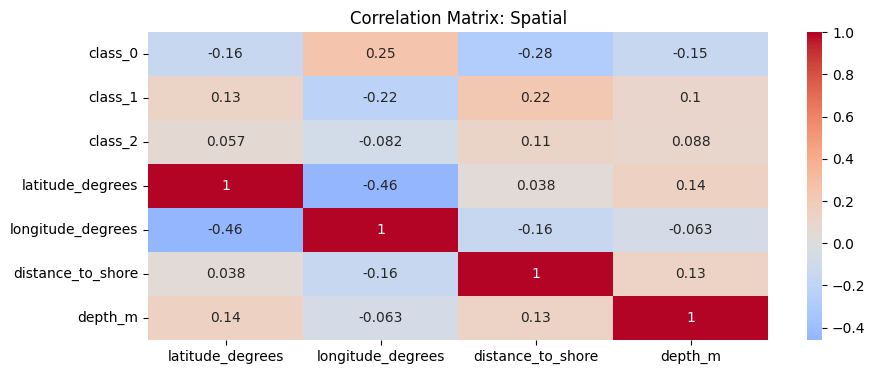


=== Spatial: Correlations >= 0.4 (moderate/high) ===
latitude_degrees   longitude_degrees   -0.459
longitude_degrees  latitude_degrees    -0.459
dtype: float64

=== Spatial: Correlations between 0.2 and  0.39 (weak) ===
longitude_degrees  class_0    0.254
distance_to_shore  class_1    0.220
longitude_degrees  class_1   -0.216
distance_to_shore  class_0   -0.278
dtype: float64


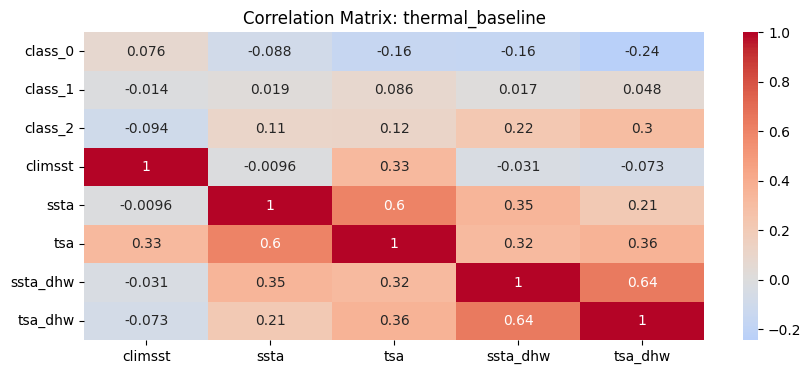


=== thermal_baseline: Correlations >= 0.4 (moderate/high) ===
tsa_dhw   ssta_dhw    0.642
ssta_dhw  tsa_dhw     0.642
tsa       ssta        0.605
ssta      tsa         0.605
dtype: float64

=== thermal_baseline: Correlations between 0.2 and  0.39 (weak) ===
tsa       tsa_dhw     0.359
tsa_dhw   tsa         0.359
ssta_dhw  ssta        0.346
ssta      ssta_dhw    0.346
climsst   tsa         0.327
tsa       climsst     0.327
          ssta_dhw    0.317
ssta_dhw  tsa         0.317
tsa_dhw   class_2     0.301
ssta_dhw  class_2     0.223
ssta      tsa_dhw     0.213
tsa_dhw   ssta        0.213
          class_0    -0.245
dtype: float64


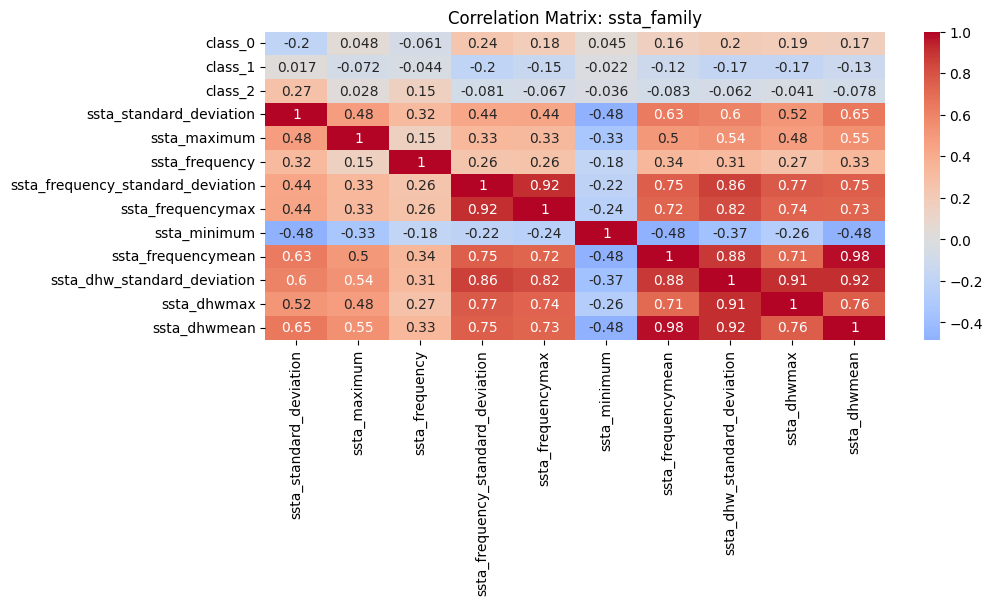


=== ssta_family: Correlations >= 0.4 (moderate/high) ===
ssta_dhwmean                       ssta_frequencymean                   0.981
ssta_frequencymean                 ssta_dhwmean                         0.981
ssta_dhwmean                       ssta_dhw_standard_deviation          0.919
ssta_dhw_standard_deviation        ssta_dhwmean                         0.919
ssta_frequencymax                  ssta_frequency_standard_deviation    0.916
ssta_frequency_standard_deviation  ssta_frequencymax                    0.916
ssta_dhw_standard_deviation        ssta_dhwmax                          0.915
ssta_dhwmax                        ssta_dhw_standard_deviation          0.915
ssta_dhw_standard_deviation        ssta_frequencymean                   0.884
ssta_frequencymean                 ssta_dhw_standard_deviation          0.884
ssta_frequency_standard_deviation  ssta_dhw_standard_deviation          0.865
ssta_dhw_standard_deviation        ssta_frequency_standard_deviation    0.865
      

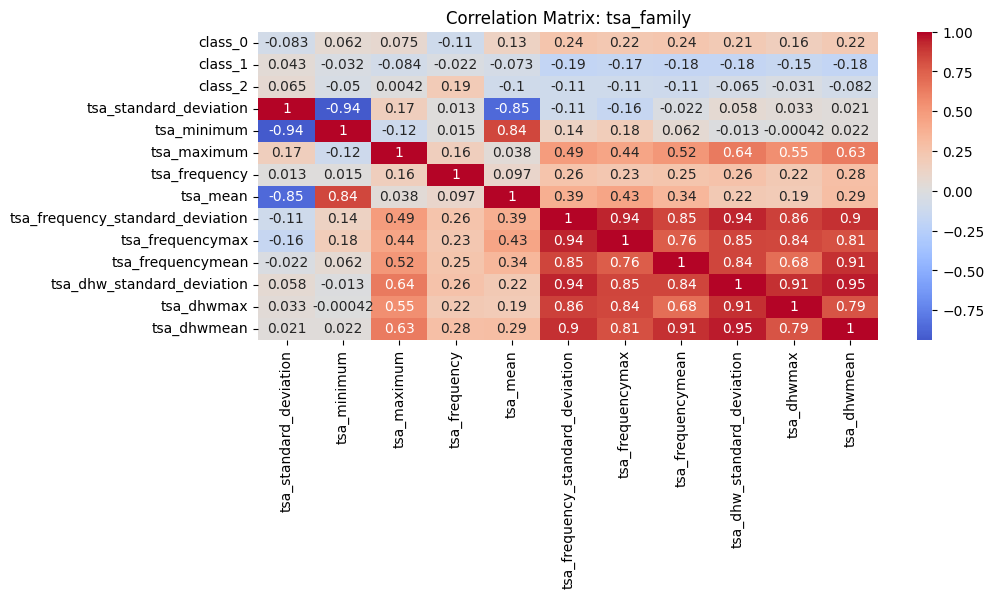


=== tsa_family: Correlations >= 0.4 (moderate/high) ===
tsa_dhw_standard_deviation        tsa_dhwmean                         0.952
tsa_dhwmean                       tsa_dhw_standard_deviation          0.952
tsa_frequency_standard_deviation  tsa_dhw_standard_deviation          0.938
tsa_dhw_standard_deviation        tsa_frequency_standard_deviation    0.938
tsa_frequencymax                  tsa_frequency_standard_deviation    0.937
tsa_frequency_standard_deviation  tsa_frequencymax                    0.937
tsa_dhwmean                       tsa_frequencymean                   0.908
tsa_frequencymean                 tsa_dhwmean                         0.908
tsa_dhwmax                        tsa_dhw_standard_deviation          0.906
tsa_dhw_standard_deviation        tsa_dhwmax                          0.906
tsa_frequency_standard_deviation  tsa_dhwmean                         0.902
tsa_dhwmean                       tsa_frequency_standard_deviation    0.902
tsa_frequency_standard_deviatio

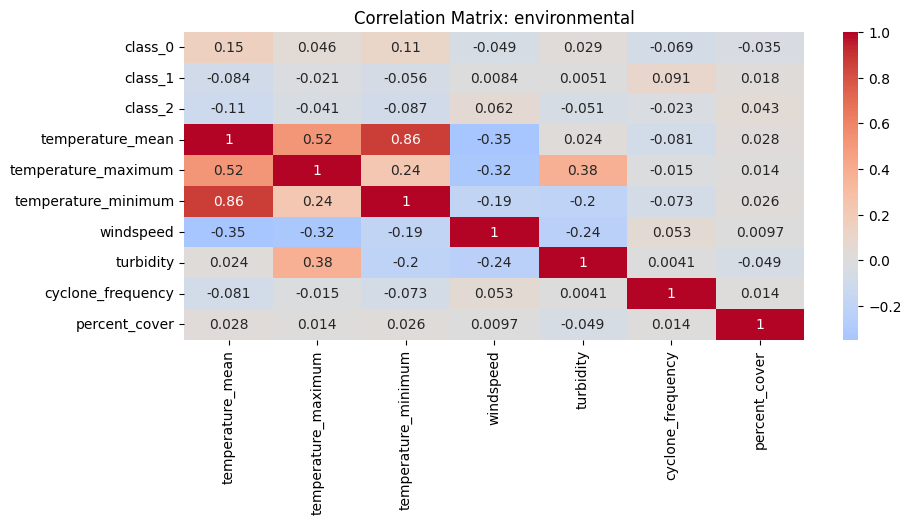


=== environmental: Correlations >= 0.4 (moderate/high) ===
temperature_mean     temperature_minimum    0.864
temperature_minimum  temperature_mean       0.864
temperature_mean     temperature_maximum    0.519
temperature_maximum  temperature_mean       0.519
dtype: float64

=== environmental: Correlations between 0.2 and  0.39 (weak) ===
temperature_maximum  turbidity              0.380
turbidity            temperature_maximum    0.380
temperature_minimum  temperature_maximum    0.237
temperature_maximum  temperature_minimum    0.237
turbidity            temperature_minimum   -0.203
temperature_minimum  turbidity             -0.203
windspeed            turbidity             -0.238
turbidity            windspeed             -0.238
windspeed            temperature_maximum   -0.322
temperature_maximum  windspeed             -0.322
temperature_mean     windspeed             -0.347
windspeed            temperature_mean      -0.347
dtype: float64


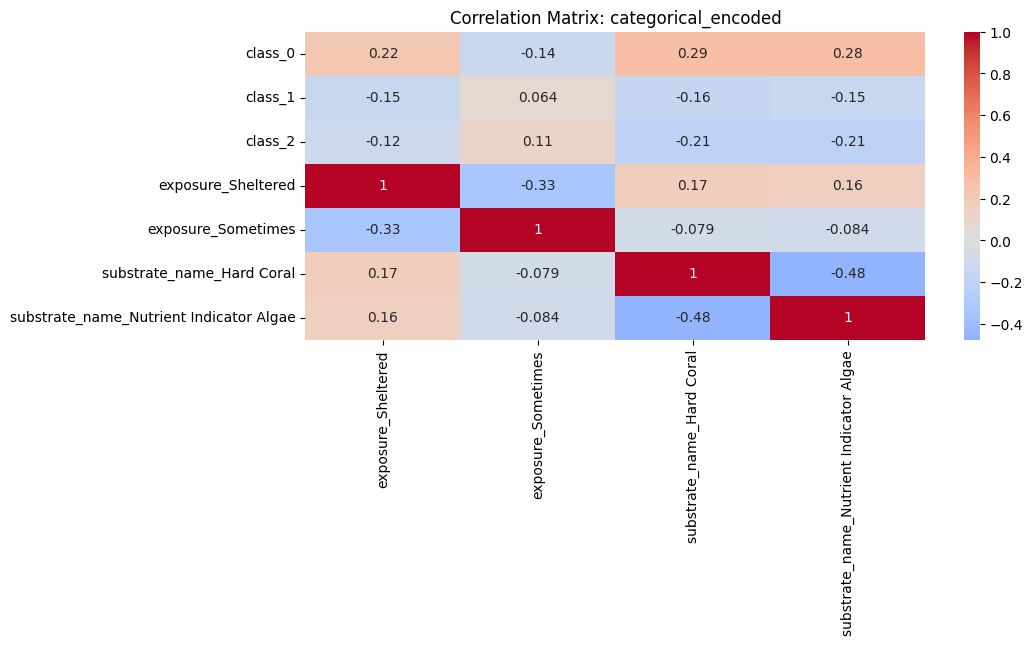


=== categorical_encoded: Correlations >= 0.4 (moderate/high) ===
substrate_name_Hard Coral                substrate_name_Nutrient Indicator Algae   -0.475
substrate_name_Nutrient Indicator Algae  substrate_name_Hard Coral                 -0.475
dtype: float64

=== categorical_encoded: Correlations between 0.2 and  0.39 (weak) ===
substrate_name_Hard Coral                class_0               0.291
substrate_name_Nutrient Indicator Algae  class_0               0.280
exposure_Sheltered                       class_0               0.217
substrate_name_Nutrient Indicator Algae  class_2              -0.211
substrate_name_Hard Coral                class_2              -0.214
exposure_Sometimes                       exposure_Sheltered   -0.333
exposure_Sheltered                       exposure_Sometimes   -0.333
dtype: float64


In [85]:
df_train_with_dummies = (
    pd.get_dummies(df_train.bleaching_class, prefix='class')
    .join(df_train.drop('bleaching_class', axis=1))
)

class_cols = [c for c in df_train_with_dummies.columns if c.startswith("class_")]

for group_name, cols in feature_groups.items():
    numeric_group_cols = [c for c in cols if c in df_train_with_dummies.columns]

    if len(numeric_group_cols) > 0:

        #method='pearson' default for corr method
        #pearson is sensitive to outliers
        #pearson for linear relationships in interval/ratio data
        #spearman for ordinal data or when the relationship is not linear
        cm = df_train_with_dummies[class_cols + numeric_group_cols].corr(method='spearman')
        cm = cm.loc[class_cols + numeric_group_cols, numeric_group_cols]
        
        plt.figure(figsize=(10, 4))
        sns.heatmap(
            cm,
            annot=True,
            cmap='coolwarm',
            center=0
        )
        
        plt.title(f"Correlation Matrix: {group_name}")
        plt.show()

        #flatten the correlation matrix and filter values
        corr_series = cm.unstack().dropna()

        #remove self‑correlations (value = 1.0)
        corr_series = corr_series[corr_series != 1.0]

        #absolute values for thresholding
        corr_abs = corr_series.abs()

        #thresholds
        weak_low = 0.20
        weak_high = 0.39
        moderate_high_low = 0.40

        print(f"\n=== {group_name}: Correlations >= {moderate_high_low} (moderate/high) ===")
        print(corr_series[corr_abs >= moderate_high_low].round(3).sort_values(ascending=False))

        print(f"\n=== {group_name}: Correlations between {weak_low} and  {weak_high} (weak) ===")
        print(corr_series[(corr_abs >= weak_low) & (corr_abs <= weak_high)].round(3).sort_values(ascending=False))



**Correlation results**:

Correlations between 0.10-0.39 were considered weak. Correlations above 0.40 were considered moderate to high.

**For logistic regression drop highly correlated features (just keep one of each correlated pair).**

1. **Spatial** - Spatial variables alone are not strong predictors of bleaching risk, which is expected as bleaching is driven mostly by thermal stress and not geography.  

2. **Thermal Baseline**:

    keep: 
    - ssta
    - tsa_dhw (slightly stronger correlation with class_2)
    - climsst

3. **SSTA family** - This group has different measures of ssta which can be redundant for linear models.

    Keep: 

    - ssta_dhwmean (strongest correlation with bleaching)
    - ssta_frequencymean (More stable)
    - ssta_maximum (Captures extreme heat events without redundancy)     

4. **TSA family** - Do not keep features if already keeping SSTA values as they are mirroing each other for linear models. 

5. **Environment**: 

    Keep:

    - temperature_maximum (best bleaching predictor)
    - turbidity
    - windspeed

6. **Categorial encoded features**:

    Keep:

    - substrate_name_Hard Coral (Most bleaching models use hard coral to measure healthy reef substrate)
    - exposure_Sheltered
    - exposure_Sometimes

**To keep in mind**:

    - tree‑based, random forest models → model handles multicolinearity
    - logistic regression / linear models → drop features with high correlations (keep just one)

#### Histogram of Classes and Features

Examine the distribution of the outcome variable (risk class) and the distribution of the features.

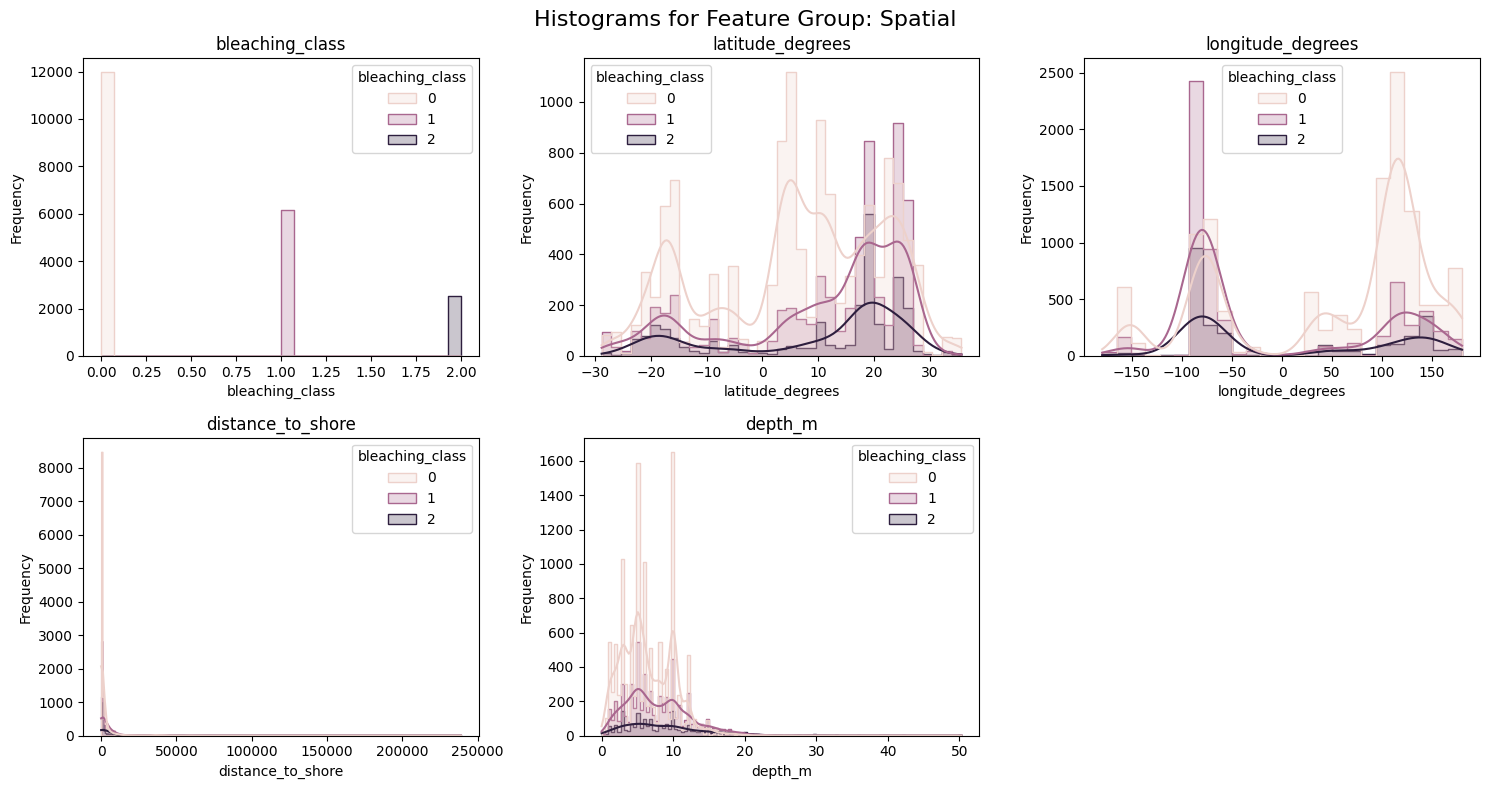

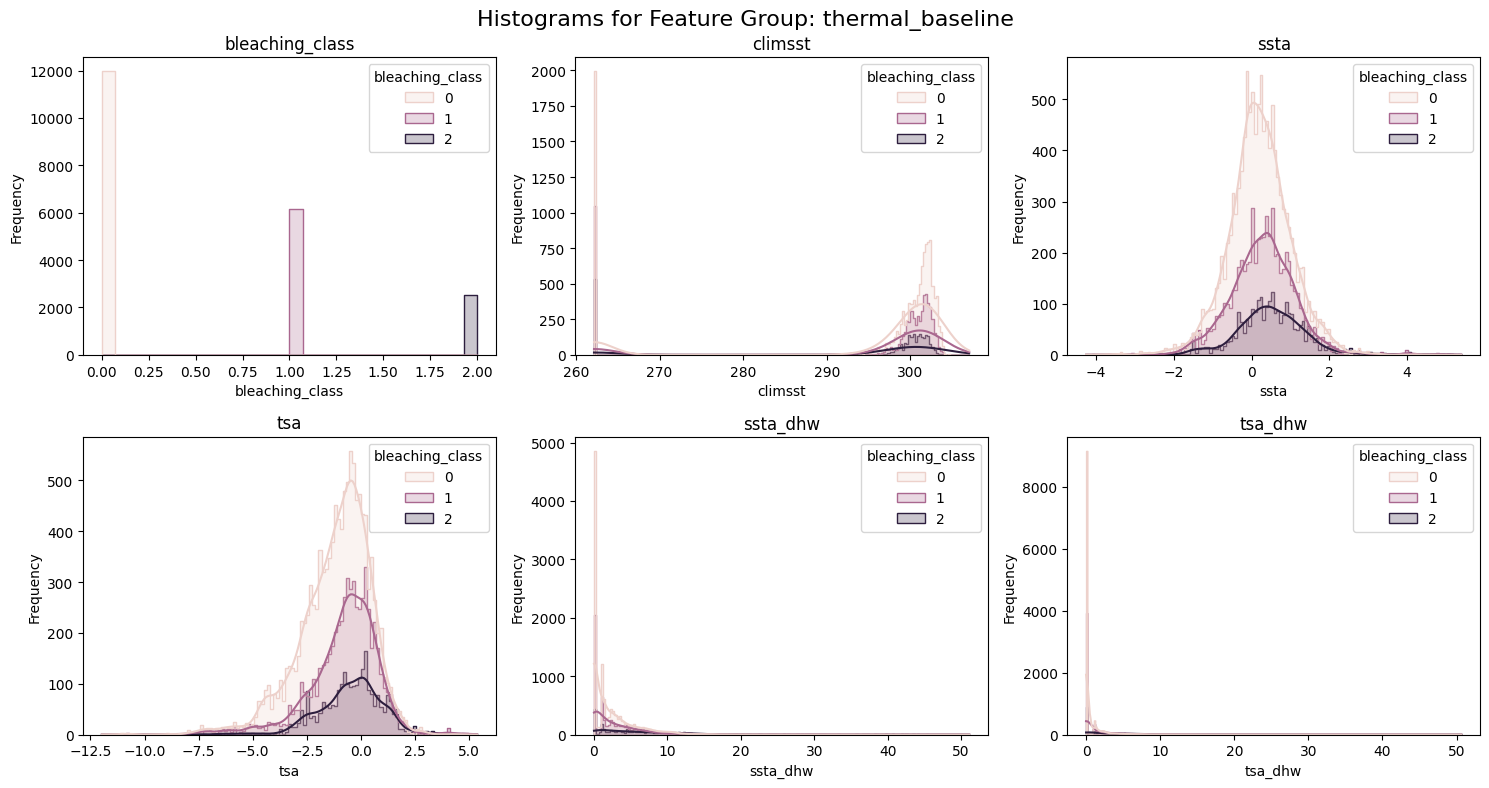

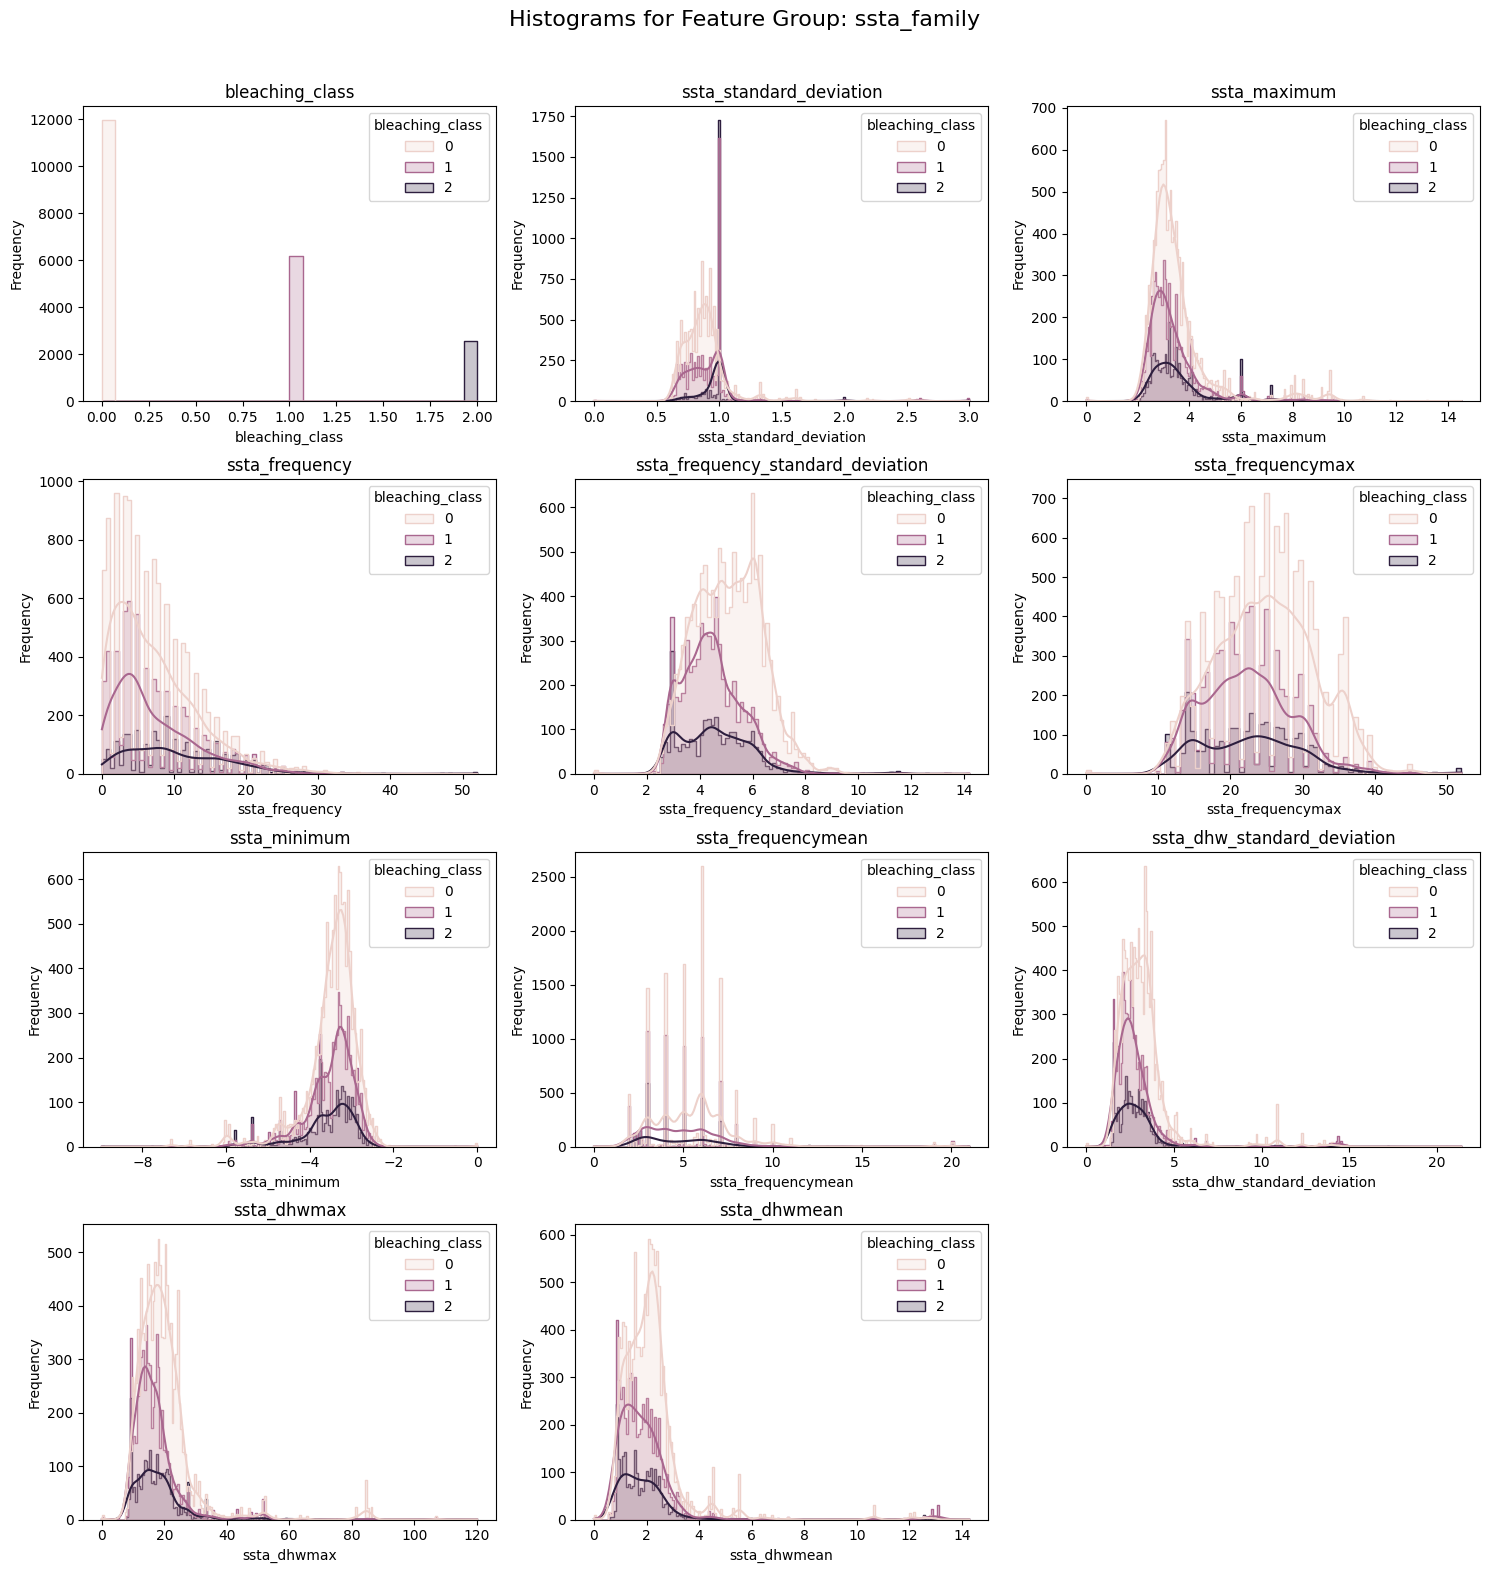

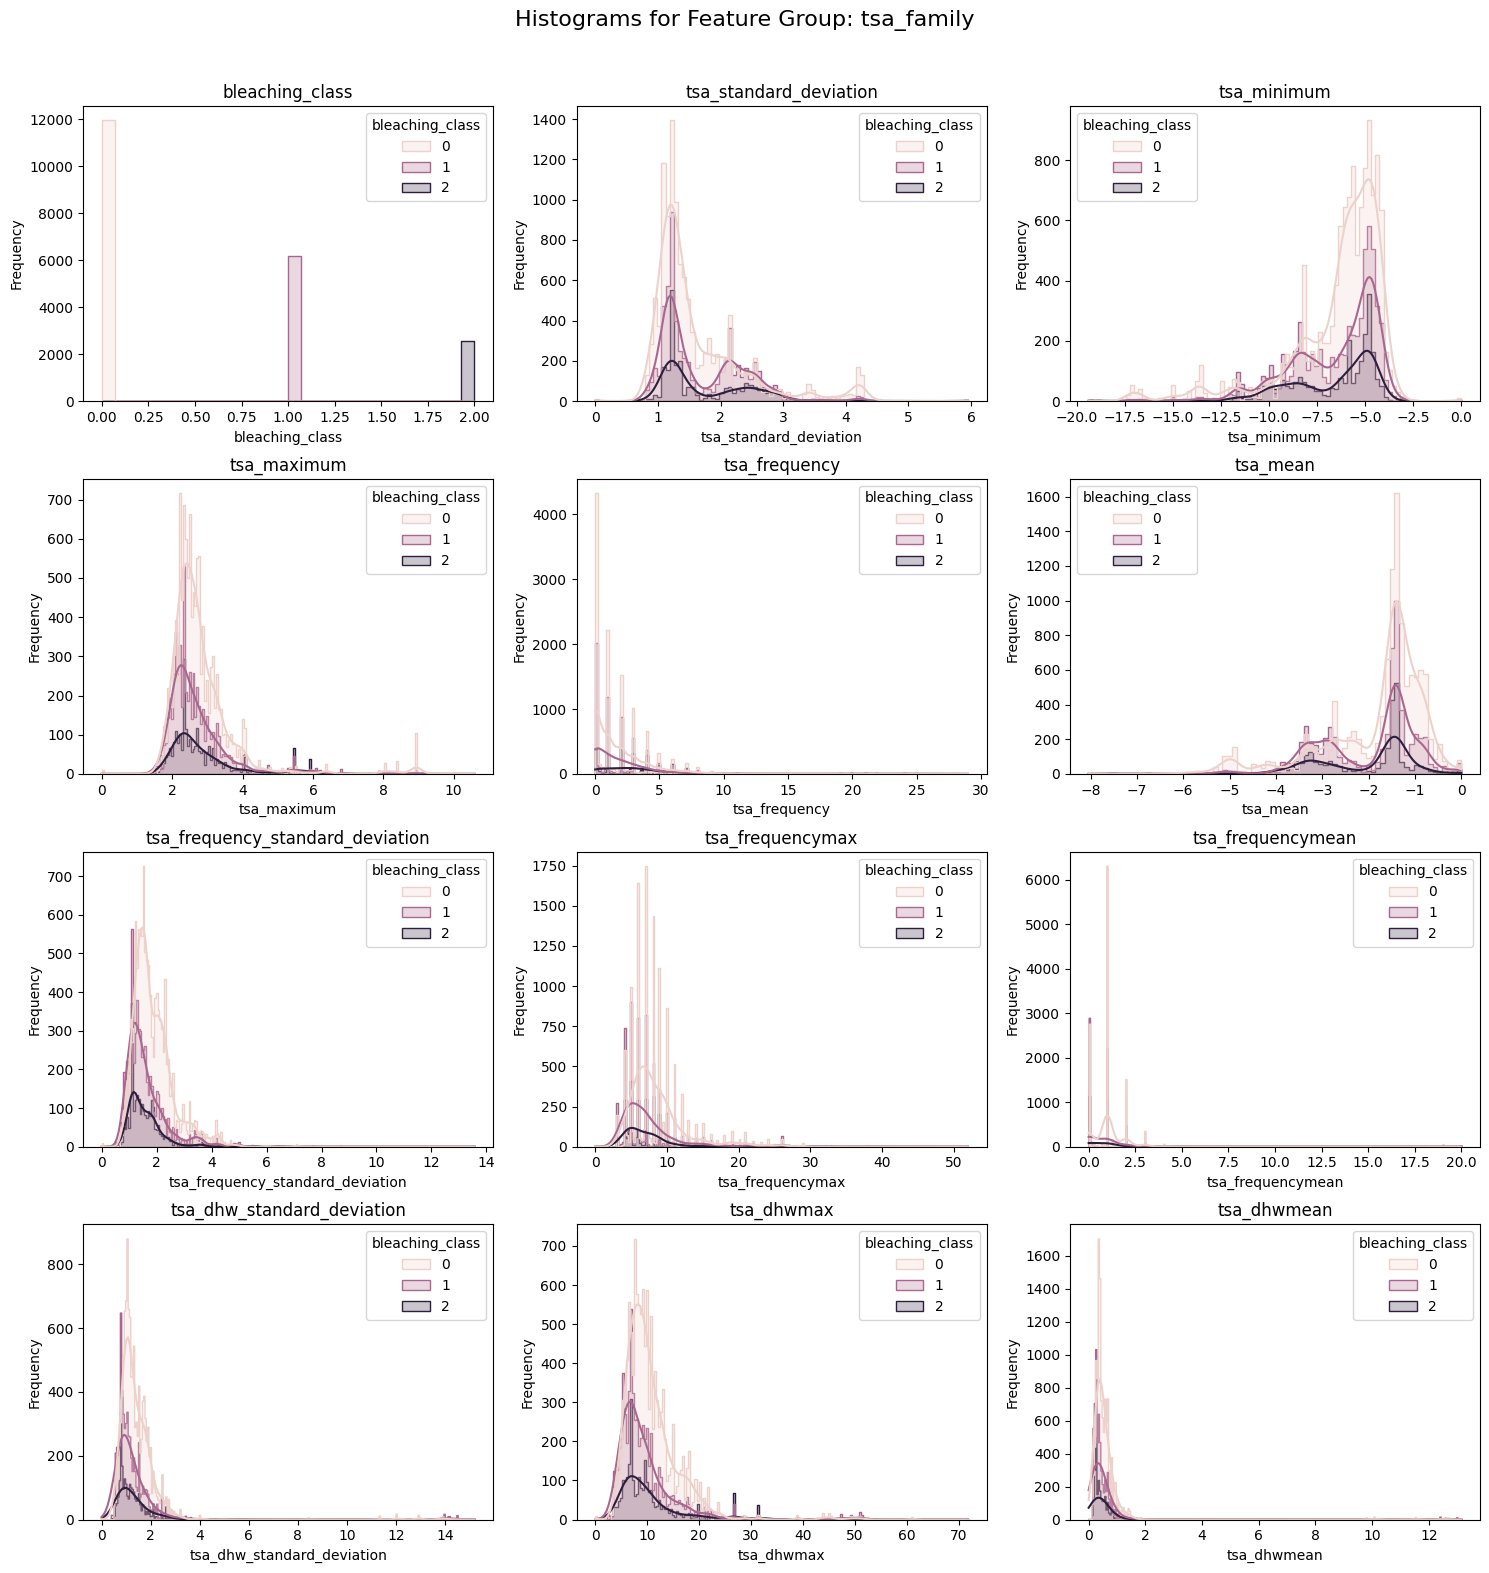

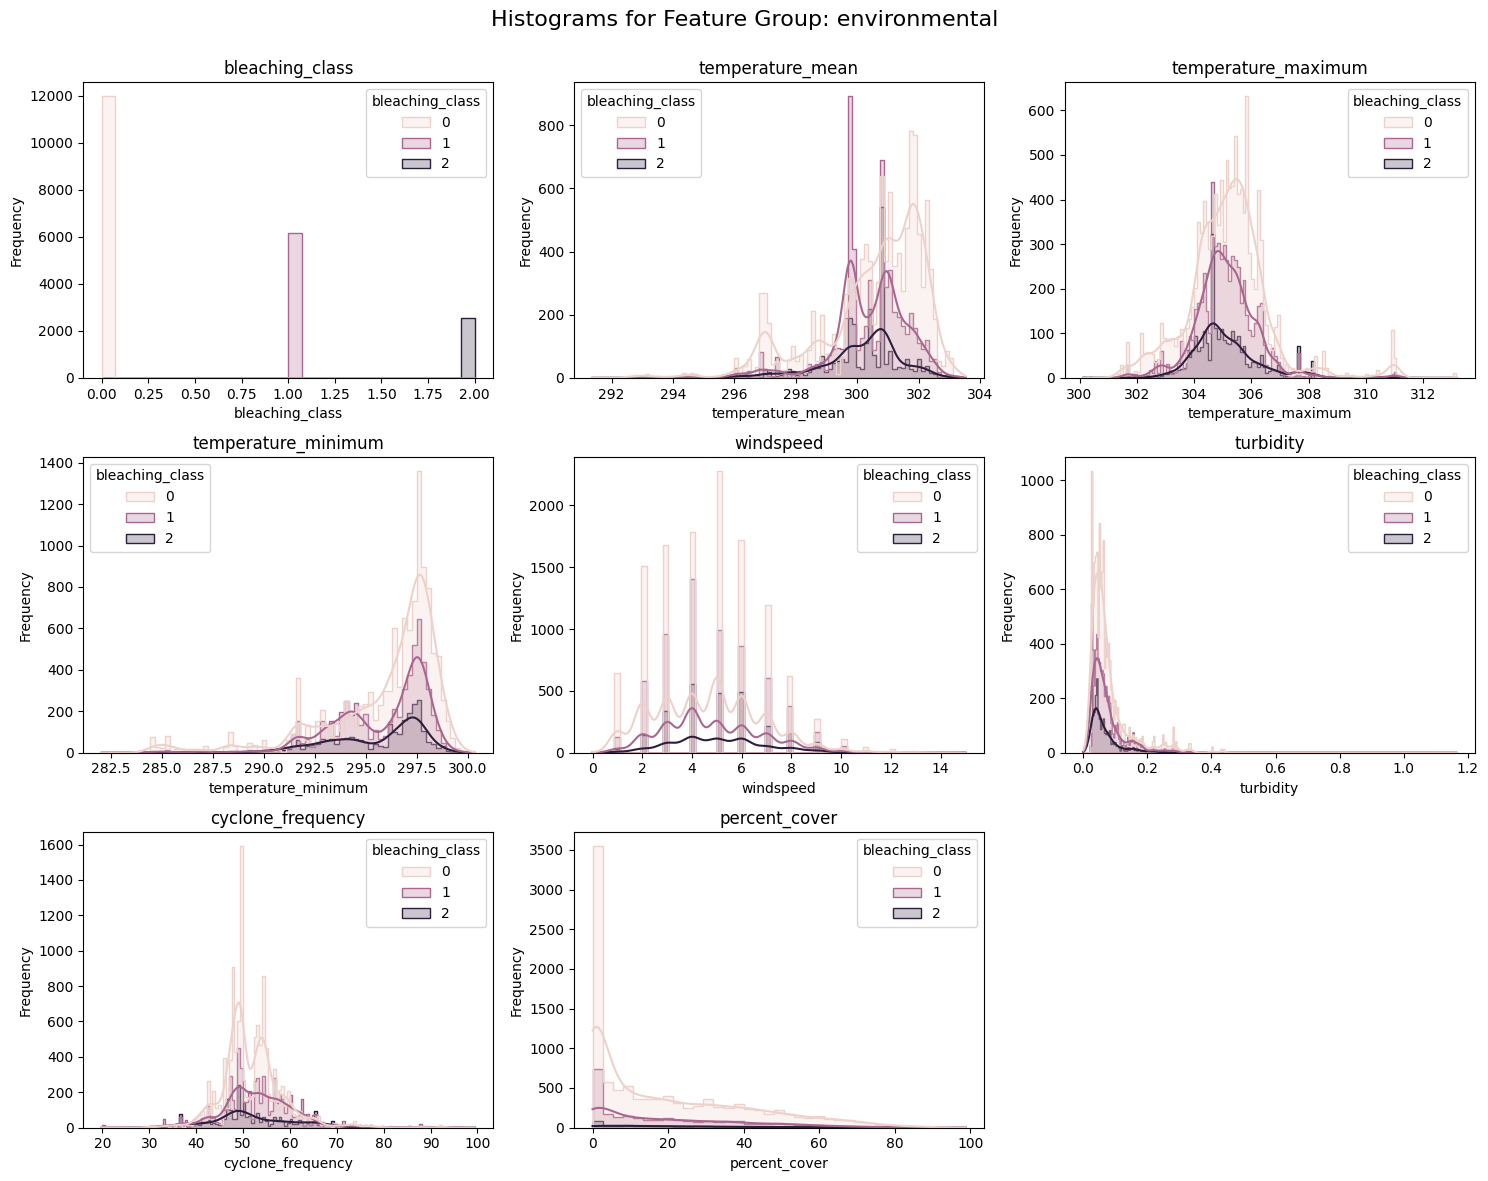

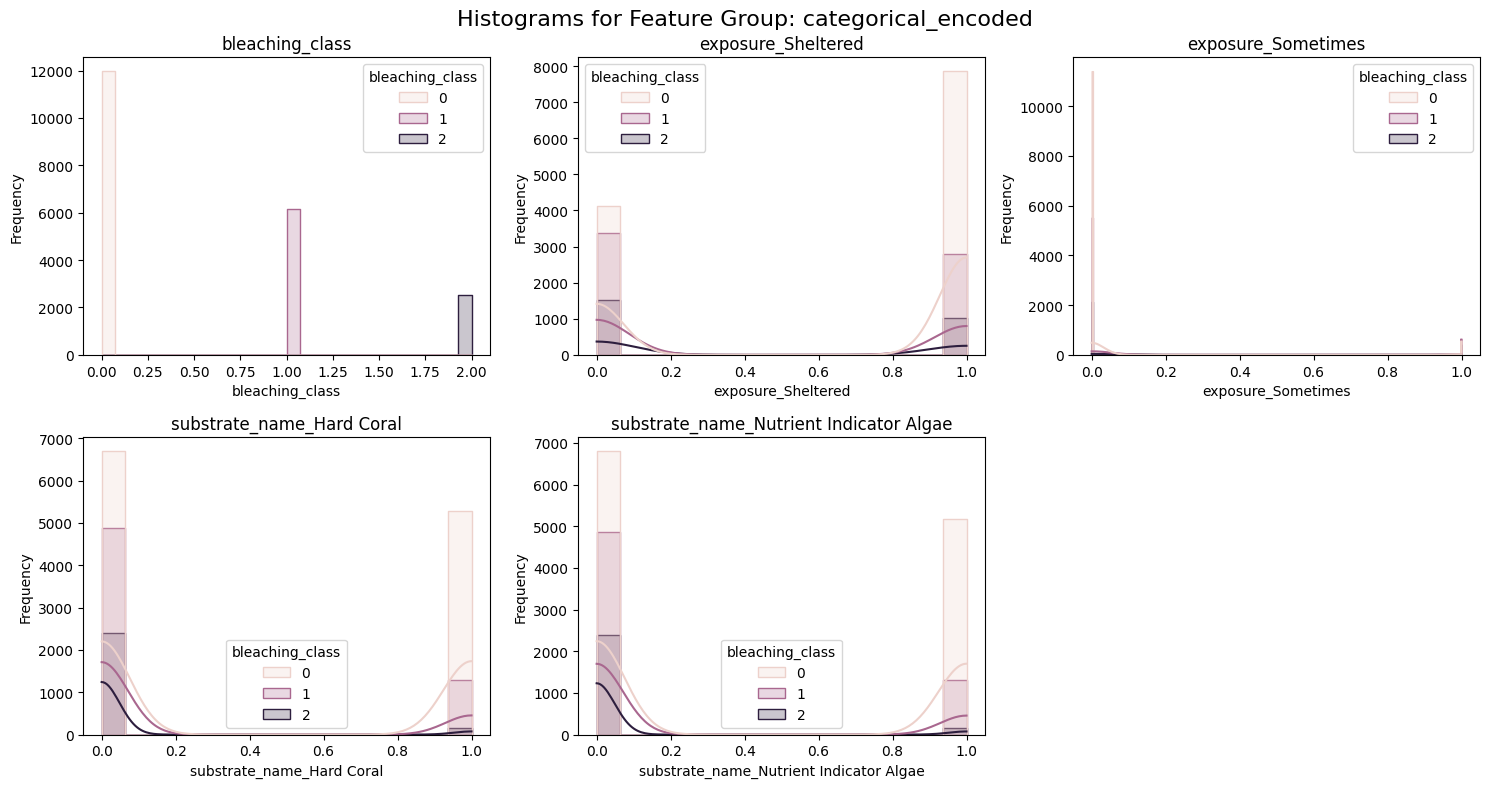

In [86]:
for group_name, cols in feature_groups.items():
    numeric_group_cols = [c for c in cols if c in df_train]
    cols_for_plot = ['bleaching_class'] + numeric_group_cols

    if len(numeric_group_cols) > 0:
        
        n = len(cols_for_plot)
        ncols = 3
        nrows = math.ceil(n / ncols)

        fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
        axes = axes.flatten()

        for ax, col in zip(axes, cols_for_plot):
            sns.histplot(
                data=df_train,
                x=col,
                hue='bleaching_class',
                kde=True,
                ax=ax,
                element='step'
            )
            ax.set_title(f"{col}")
            ax.set_ylabel("Frequency")

        for ax in axes[n:]:
            ax.axis('off')

        fig.suptitle(f"Histograms for Feature Group: {group_name}", fontsize=16)
        fig.tight_layout()
        fig.subplots_adjust(top=0.92)

        plt.show()


In the histogram of classes and features, we observed that the ‘bleaching_class’ variable is imbalanced as found previously, with low risk (0) being more frequent than others. 

Thermal baseline features shows how most features overlap between classes, suggesting that while thermal conditions vary, the separation per class is not highly defined. 

SSTA family group shows some features like ssta_dhwmean, ssta_dhwmax, and ssta_dhw_standard_deviation display some shifts in the distribution shape and peaks across classes, which could be relevant for predicting bleaching risks. Similar with frequency based metrics. TSA family groups since mirrors SSTA shows similar story. 

The environmental group shows how ecological and physical conditions vary across the target classes. Windspeed and turbidity display more dispersed patters than temperature based metrics, which could be influencial on local stress conditions. 

Categorical encoded features like exposure and substrate names, shows distinct class proportions which can be influencing for bleaching levels. Substratre features shows the contrast between healthy coral cover which aligns with lower risk, while algae-dminated sites have a higher frequency in higher risk categories. 